# Further analysis on the frequency model

First, let's load the challenge's data and target and join them on ``ID``

In [13]:
import pandas as pd

data_path = "../data/"

# loading x_train
data = pd.read_csv(data_path+'train_input_Z61KlZo.csv')
data.set_index('ID', inplace=True)
print("x_train", data.shape)

# loading target
target = pd.read_csv(data_path+'train_output_DzPxaPY.csv')
target.set_index('ID', inplace=True)
print("y_train", target.shape)

# joining x_train and y_train
data = data.join(target.drop("ANNEE_ASSURANCE", axis=1))
print("data", data.shape)

/var/folders/qf/pxq_c1s53jn0j_nkpfcjpxfm0000gn/T/ipykernel_7830/2176795849.py:6: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path+'train_input_Z61KlZo.csv')


x_train (383610, 373)
y_train (383610, 4)
data (383610, 376)


## Defining multiclass target

Has defined in the data dictionary, the number of claims is ``FREQ`` x ``ANNEE_ASSURANCE``, it will be our target variable

In [14]:
target_col = "TARGET"
data[target_col] = (data["FREQ"] * data["ANNEE_ASSURANCE"]).astype(int)
data[target_col].value_counts(normalize=False).sort_index()

TARGET
0    381060
1      2462
2        84
3         2
4         1
5         1
Name: count, dtype: int64

## Stratified Sampling & Weighting

**Stratified Sampling** is applied to ensure same distribution between train (80%) and dev (20%) samples

**Weights** are computed as the inverse frequency of each class of the target, giving more weights to rare classes like (ie observed claims)




**Note:** observations with more than 2 claims are scarce (only 4 of them), they are merged with those that have 2 claims, defining the following multiclass target `Y`:
* `0`: no claim
* `1`: one claim
* `2`: two or more claims

In [15]:
import numpy as np

from collections import Counter
from sklearn.model_selection import train_test_split

y_transform = lambda u: u.where(u <= 1, 2)  # Transform the target variable to ensure binary classification

# Compute class frequencies
class_counts = Counter(y_transform(data[target_col]))
total_samples = len(data[target_col])

# Compute inverse frequency class weights
class_weights = {cls: total_samples / (len(class_counts) * count) for cls, count in class_counts.items()}
print("Class weights:", class_weights)

# Assign sample weights based on target values
weights = np.array([class_weights[label] for label in y_transform(data[target_col])])

# Train-test split
x_train, x_dev, y_train, y_dev, w_train, w_dev = train_test_split(data, data[target_col], weights, test_size=0.2, random_state=42, stratify=y_transform(data[target_col]))
print("y_train mean", y_train.mean())
print("y_dev mean", y_dev.mean())

Class weights: {0: 0.33556395318322574, 1: 51.9374492282697, 2: 1453.0681818181818}
y_train mean 0.006888506556137744
y_dev mean 0.006921091733792133


# Feature Engineering

The `Processor` class is used to build several new features:
* `ZONE` is converted to `ZONE_REGION`
* Copies of `ALTITUDE_xxx`, `IND_xxx`, `MEN_xxx` and `LOG_xxx` are converted to numerical features: `ALTITUDE_xxx_num`, `IND_xxx_num`, `MEN_xxx_num` and `LOG_xxx_num`
* Vetusty of buildings is computed: `LOG_VETUSTE`
* It learns the distribution of `LOG_TOT`, `LOG_VETUSTE`, `MEN_TOT`, `IND_TOT`, `IND_SNV`,`ALTITUDE_TOT` per `ZONE_REGION`on train sample. It's then used to compute the ratio of each sample to its mean per region (sort of a measure of divergence from the regional mean)
* Per observation, `CA_TOT` and `CA_MEAN` are computed as the sum and mean of `CA1`, `CA2` and `CA3`. `CA_TOT` and `CA_MEAN` are used to compute ratios with  `CA1`, `CA2` and `CA3`
* Open Source data from [Base de Données sur les Incendies de Forêts en France](https://bdiff.agriculture.gouv.fr/) are added: fire extinction rates per `ZONE` in 2023, total surfaces burnt in 2023 and in the 2016-2020 period per `ZONE`, surface burnt over surface of forest per `ZONE` in 2023. Those features are crossed with `NB_CASERNES` and `ZONE_VENT`
* Numerical `KAPITAL_xxx` columns are sumed and maxed out into `KAPITAL_SUM` and `KAPITAL_MAX`
* Temperature columns are crossed with one another
* Binary non-numerical columns are one hot encoded

In [16]:
import warnings
from utils.data_toolkit import Processor
from pandas.errors import PerformanceWarning

warnings.simplefilter(action='ignore', category=FutureWarning)
# warnings.simplefilter(action='ignore', category=PerformanceWarning)

proc = Processor()
x_train = proc.fit_transform(x_train)
x_dev = proc.transform(x_dev)
data = proc.transform(data)

### Load Carvers

In [17]:
from AutoCarver import MulticlassCarver

version = "010"
carver_numericals = MulticlassCarver.load(f"{data_path}/{version}_carver_numericals.json")
carver_numericals.summary

content  target_mean  \
feature                              label                              
Quantitative('ANCIENNETE__y=1')      0      x <= 0.0e+00     0.005282   
                                     1       0.0e+00 < x     0.006573   
Quantitative('TYPBAT2__y=1')         0      x <= 0.0e+00     0.004975   
                                     1       0.0e+00 < x     0.007069   
Quantitative('KAPITAL6__y=1')        0      x <= 0.0e+00     0.003562   
...                                                  ...          ...   
Quantitative('ALTITUDE_REGION__y=2') 1       9.7e-03 < x     0.000263   
Quantitative('Unknown__y=2')         0      x <= 1.0e+01     0.000265   
                                     1       1.0e+01 < x     0.000225   
Quantitative('Malveillance__y=2')    0      x <= 0.0e+00     0.000154   
                                     1       0.0e+00 < x     0.000260   

                                            frequency  
feature                              label             
Quantitative('ANCIENNETE__y=1')      0       0.128923  
                                     1       0.871077  
Quantitative('TYPBAT2__y=1')         0       0.316353  
                                     1       0.683647  
Quantitative('KAPITAL6__y=1')        0       0.573584  
...                                               ...  
Quantitative('ALTITUDE_REGION__y=2') 1       0.235004  
Quantitative('Unknown__y=2')         0       0.098212  
                                     1       0.855074  
Quantitative('Malveillance__y=2')    0       0.275733  
                                     1       0.677553  

[538 rows x 3 columns]

In [18]:
from AutoCarver import MulticlassCarver

version = "010"
carver = MulticlassCarver.load(f"{data_path}/{version}_carver.json")
carver.summary

content  \
feature                          label                                                      
Categorical('ACTIVIT2__y=1')     0                                     [ACT3, ACT8, ACT2]   
                                 1                                           [ACT9, ACT1]   
                                 2                    [ACT4, ACT6, ACT7, __OTHER__, ACT5]   
Categorical('VOCATION__y=1')     0        [VOC7, VOC5, VOC3, VOC2, __OTHER__, VOC8, VOC1]   
                                 1                                           [VOC6, VOC4]   
...                                                                                   ...   
Ordinal('LOG_SOC__y=2')          1      [04. <= 40, 05. <= 50, 06. <= 60, 07. <= 70, 0...   
Ordinal('DISTANCE_142__y=2')     0                                  [02. <= 17, 01. <= 8]   
                                 1                               [04. >= 946, 03. <= 946]   
Ordinal('FXI3SAB_VOR_MM_A__y=2') 0                                               01. <= 8   
                                 1                      [04. >= 24, 03. <= 24, 02. <= 17]   

                                        target_mean  frequency  
feature                          label                          
Categorical('ACTIVIT2__y=1')     0         0.000000   0.066037  
                                 1         0.000220   0.785023  
                                 2         0.000438   0.148940  
Categorical('VOCATION__y=1')     0         0.000010   0.322512  
                                 1         0.000346   0.677488  
...                                             ...        ...  
Ordinal('LOG_SOC__y=2')          1         0.000840   0.023269  
Ordinal('DISTANCE_142__y=2')     0         0.000303   0.375824  
                                 1         0.000575   0.056698  
Ordinal('FXI3SAB_VOR_MM_A__y=2') 0         0.000364   0.340072  
                                 1         0.000247   0.092451  

[1342 rows x 3 columns]

In [19]:
x_train = carver_numericals.transform(x_train)
x_train = carver.transform(x_train)
x_dev = carver_numericals.transform(x_dev)
x_dev = carver.transform(x_dev)

In [20]:
import json

best_features = json.load(open(f"{data_path}/{version}_best_features.json"))
best_features

['KAPITAL32',
 'KAPITAL12',
 'SURFACE10',
 'SURFACE1',
 'SURFACE7',
 'KAPITAL21',
 'NBBAT4',
 'NBSINSTRT',
 'KAPITAL23',
 'EQUIPEMENT6',
 'NBSINCONJ',
 'SURFACE17',
 'KAPITAL8',
 'TAILLE3',
 'KAPITAL14',
 'KAPITAL24',
 'KAPITAL27',
 'KAPITAL3',
 'KAPITAL10',
 'NBBAT2',
 'EQUIPEMENT1',
 'DEROG1',
 'SURFACE13',
 'CARACT5',
 'NBBAT7',
 'RISK5',
 'NBBAT8',
 'KAPITAL20',
 'ZONE_VENT',
 'KAPITAL17',
 'KAPITAL25',
 'RISK2',
 'NBBAT6',
 'ALTITUDE_2_num',
 'ALTITUDE_5_num',
 'DEROG11',
 'RISK1',
 'NBBAT9',
 'KAPITAL1',
 'DEROG10',
 'DUREE_REQANEUF',
 'DEROG7',
 'EQUIPEMENT4',
 'DEROG6',
 'RISK4',
 'IND_Y8_Y9_num',
 'TYPBAT2',
 'MEN_1IND_MEN_TOT',
 'ALTITUDE_4_num',
 'ALTITUDE_4_ALT_TOT',
 'KAPITAL32__y=1',
 'SURFACE10__y=2',
 'SURFACE7__y=2',
 'KAPITAL32__y=2',
 'SURFACE4__y=2',
 'SURFACE2__y=1',
 'SURFACE3__y=1',
 'KAPITAL12__y=1',
 'SURFACE11__y=1',
 'TAILLE1__y=2',
 'SURFACE11__y=2',
 'NBBAT4__y=1',
 'KAPITAL6__y=2',
 'TAILLE2__y=2',
 'VOCATION__y=2',
 'KAPITAL21__y=1',
 'KAPITAL12__y=2',
 '

In [21]:
assert all([col in x_train.columns for col in best_features]), "Some features are missing in the training set"

### Load model 

In [22]:
### Loading model
from xgboost import XGBClassifier

model = XGBClassifier()
model.load_model(data_path+'012_xgboost.json')

### Feature importance and explanation

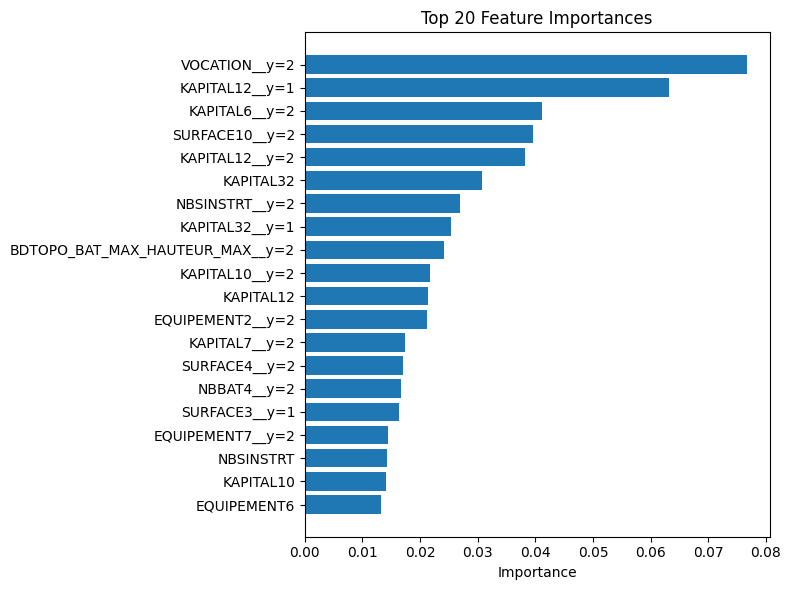

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances and feature names
importances = model.feature_importances_
features = model.get_booster().feature_names

# Create a DataFrame for better visualization
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

In [24]:
# Get features and their importances, sort by importance descending
feature_importance_list = sorted(zip(features, importances), key=lambda x: x[1], reverse=True)
ordered_features = [u[0] for u in feature_importance_list]
ordered_features
# for feature, importance in feature_importance_list:
#     print(f"{feature}: {importance:.6f}")

['VOCATION__y=2',
 'KAPITAL12__y=1',
 'KAPITAL6__y=2',
 'SURFACE10__y=2',
 'KAPITAL12__y=2',
 'KAPITAL32',
 'NBSINSTRT__y=2',
 'KAPITAL32__y=1',
 'BDTOPO_BAT_MAX_HAUTEUR_MAX__y=2',
 'KAPITAL10__y=2',
 'KAPITAL12',
 'EQUIPEMENT2__y=2',
 'KAPITAL7__y=2',
 'SURFACE4__y=2',
 'NBBAT4__y=2',
 'SURFACE3__y=1',
 'EQUIPEMENT7__y=2',
 'NBSINSTRT',
 'KAPITAL10',
 'EQUIPEMENT6',
 'SURFACE11__y=1',
 'TAILLE2__y=2',
 'NBBAT7',
 'KAPITAL14',
 'RISK2',
 'KAPITAL8',
 'TAILLE1__y=2',
 'BDTOPO_BAT_MAX_HAUTEUR__y=2',
 'SURFACE1',
 'AN_EXERC__y=2',
 'NBBAT4',
 'SURFACE11__y=2',
 'KAPITAL37__y=2',
 'MEN_1IND_MEN_TOT',
 'ALTITUDE_4_num',
 'RISK1',
 'NBBAT9',
 'RISK5',
 'KAPITAL21',
 'RISK11__y=2',
 'RISK4',
 'SURFACE10',
 'DEROG11',
 'HAUTEUR_MAX__y=2',
 'KAPITAL14__y=2',
 'KAPITAL23',
 'NBSINCONJ',
 'SURFACE7',
 'TYPBAT2',
 'HAUTEUR__y=2',
 'ALTITUDE_4_ALT_TOT',
 'KAPITAL42__y=2',
 'NBBAT8',
 'TXAB_VOR_MM_A_TXAB_VOR_MMAX_A__y=2',
 'SURFACE7__y=2',
 'TAILLE3',
 'KAPITAL25',
 'KAPITAL17',
 'KAPITAL25__y=1',
 

In [25]:
import shap

# Create a TreeExplainer for the XGBoost model
explainer = shap.TreeExplainer(model, model_output='raw')

# Calculate SHAP values for the training set
shap_values = explainer.shap_values(x_train[ordered_features])

/Users/zachariebuisson/Documents/GitHub/hackathon_caa25/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Figure size 640x480 with 0 Axes>

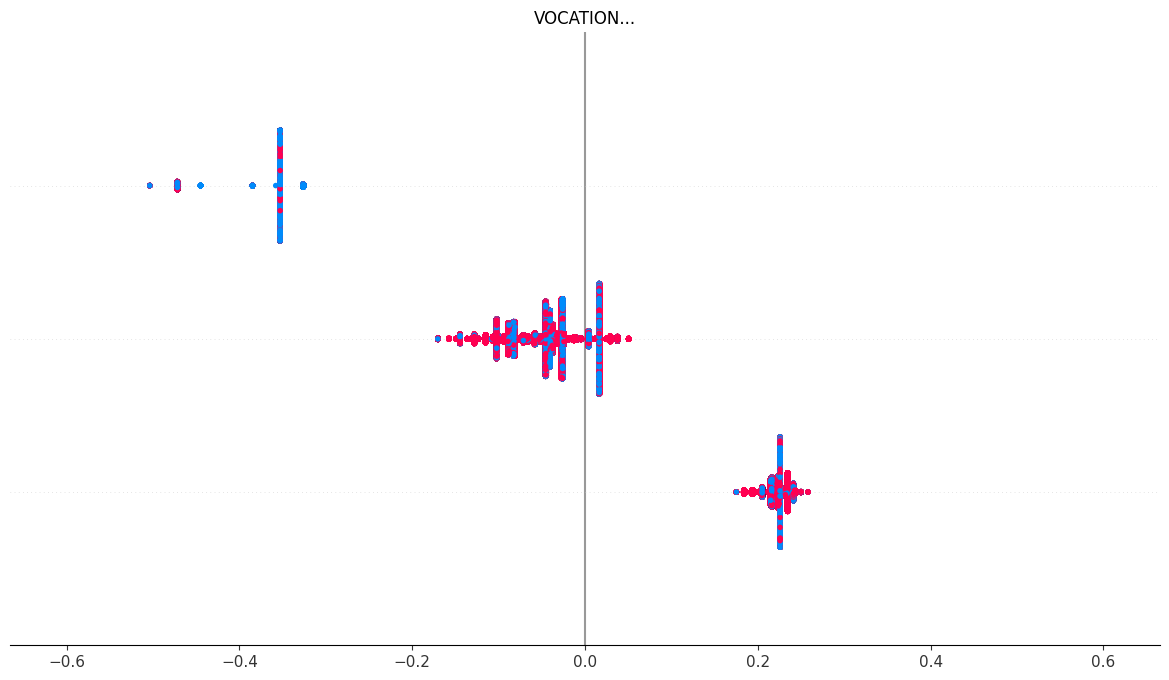

In [26]:
# Plot SHAP summary plot for all features
shap.summary_plot(shap_values, x_train[ordered_features], show=True)

In [25]:
y_train.value_counts()

TARGET
0    304848
1      1970
2        68
3         1
5         1
Name: count, dtype: int64